In [1]:
annotations = ["Walk very\nslow", "Normal\nWalk", "Nordic Walk", "Run", "Cycle", "Run", "Normal\nWalk", "Soccer", "Rope\nJump"]

In [2]:
k_max = 100

In [3]:
window_size = 160

In [4]:
# rwalk = series[2000:3000]
# rtopn = ScampiTopN(rwalk, k_max=10, window_size=100, top_N=10)
# rtopn.mask[200: 800] = 1

# plt.plot(rwalk, label="original", lw=3)
# masked = rtopn.apply_mask()
# print(masked.shape, rwalk.shape)
# plt.plot(masked, label="masked")
# plt.legend()

In [5]:
import marimo as mo
import os
import numpy as np
import pandas as pd
import scampi
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.simplefilter("ignore")

The 7-th motiflet appears between activities

<hr />

# Appendix: utilities

In [6]:
from scampi.scampi import SCAMPI

In [7]:
colors = sns.color_palette("tab20")

In [8]:
def load_dataset(dataset, selection=None):
    desc_filename = f"../datasets/{dataset}/desc.txt"
    desc_file = []

    with open(desc_filename, 'r') as file:
        for line in file.readlines(): desc_file.append(line.split(","))

    df = []

    for idx, row in enumerate(desc_file):
        if selection is not None and idx not in selection: continue
        (ts_name, window_size), change_points = row[:2], row[2:]
        if len(change_points) == 1 and change_points[0] == "\n": change_points = list()
        path = f'../datasets/{dataset}/'

        if os.path.exists(path + ts_name + ".txt"):
            ts = np.loadtxt(fname=path + ts_name + ".txt", dtype=np.float64)
        else:
            ts = np.load(file=path + "data.npz")[ts_name]

        df.append((ts_name, int(window_size), np.array([int(_) for _ in change_points]), ts))

    return pd.DataFrame.from_records(df, columns=["name", "window_size", "change_points", "time_series"])

In [9]:
def load_pamap():
    dataset="PAMAP"
    selection = [126, 127, 128] # Outdoor
    df_data = load_dataset(dataset)

    ts_name = df_data["name"].iloc[selection]
    ts = df_data.time_series.iloc[selection]
    cps = df_data.change_points.iloc[selection[0]]

    X = np.zeros((len(ts.values), len(ts.values[0])))
    for i, data in enumerate(ts.values):
        X[i] = data

    cps = np.concatenate([[0], cps, [X.shape[1]]])

    series = pd.DataFrame(data=X, index=ts_name)
    series.rename(index={'PAMAP_Outdoor_Subject8_IMU_Shoe_X-Acc': 'Shoe X-Acc', 
                         'PAMAP_Outdoor_Subject8_IMU_Shoe_Y-Acc': 'Shoe Z-Acc', 
                         'PAMAP_Outdoor_Subject8_IMU_Shoe_Z-Acc': 'Shoe Y-Acc'}, inplace=True)

    ## series = series.iloc[0, :]
    series = series.loc[["Shoe X-Acc"]]
    return series, cps

In [10]:
series_df, changepoints = load_pamap()
series = series_df.values[0,:]

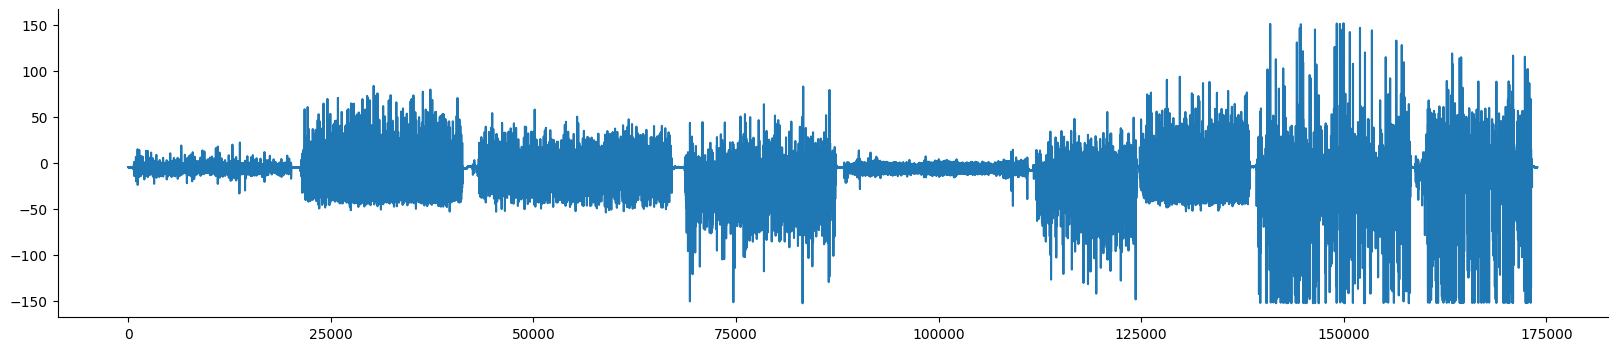

In [41]:
plt.figure(figsize=(20, 4))
plt.plot(series)
sns.despine()
plt.savefig("pamap.svg")

In [12]:
n = series.shape[0]

In [13]:
def plot_data(series, annotations, ax=None):
    if not ax:
        fig, ax = plt.subplots(figsize=(20, 5))

    tick_offsets = []
    first_label = {}
    offset = 0
    factor = 16
    for dim in range(series.shape[0]):
        for i, (a, b) in enumerate(zip(cps[:-1], cps[1:])):
            dim_data = series.iloc[dim, a:b]
            label = annotations[i]    
            c = colors[mapping[label] % len(colors)]
            if not label in first_label:
                first_label[label] = label
                sns.lineplot(x=np.arange(a,b,factor), linewidth=1, y=dim_data[::factor]+offset, ax = ax, label=label, color=c)
            else: 
                sns.lineplot(x=np.arange(a,b,factor), linewidth=1, y=dim_data[::factor]+offset, ax = ax, color=c)
            ax.axvline(x=b, color="black", linestyle="--", linewidth=1)    
        tick_offsets.append(offset)
        offset -= 1.2 * (series.iloc[dim].values.max() - series.iloc[dim].values.min())    

    ax.set_yticks(tick_offsets)
    ax.set_yticklabels(y_labels)
    ax.set_ylabel("")
    sns.despine()
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=10, fontsize=12)

    # ax.legend().set_visible(False)
    # ax.axis('off')
    plt.tight_layout()

In [14]:
def moving_average(a, n):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret / n

In [15]:
class ScampiTopN(object):
    def __init__(self, series, k_max, window_size, top_N):
        self.series = series
        self.k_max = k_max
        self.window_size = window_size
        self.top_N = top_N
        self.found_motiflets = []
        self.mask = np.zeros_like(series)
        self.rng = np.random.default_rng(1234)

    def apply_mask(self):
        mavg = moving_average(self.series, self.window_size) * self.mask
        noise = self.rng.normal(scale=np.abs(mavg), size=self.mask.shape) * self.mask
        noise += mavg
        reset_series = self.series * (1 - self.mask)
        return reset_series + noise

    def __next__(self):
        if len(self.found_motiflets) >= self.top_N:
            return None
        series = self.apply_mask()
        ml = SCAMPI(
            "Human Activity",
            series,
            n_jobs=-1,
            backend="scampi",
            verbose=False,
            scampi_delta=0.1,
        )
        dists, motif_sets, elbow_points = ml.fit_k_elbow(
            k_max=self.k_max,
            motif_length=self.window_size,
            plot_elbows=False,
            plot_motifs_as_grid=False,
        )
        for elbow in elbow_points:
            motiflet = motif_sets[elbow][0][0]
            for i in motiflet:
                self.mask[i-2*self.window_size:i+int(3*self.window_size)] = 1
        print("masked timestamps:", np.sum(self.mask))
        self.found_motiflets.append((dists, motif_sets, elbow_points))
        return dists[elbow_points], motif_sets[elbow_points]




In [16]:
topn = ScampiTopN(series, 100, 200, 12)
iteration = 0
while True:
    res = next(topn)
    if res is None:
        break

[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 6.670200668
	Time for Test 6.998961739
masked timestamps: 8031.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 7.625712414
	Time for Test 5.697584954
masked timestamps: 29725.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


...

	Time for Build 11.048620528
	Time for Test 9.896443507
masked timestamps: 92852.0
	Time for Build 11.171233135
	Time for Test 10.018709787
masked timestamps: 101630.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.861439529
	Time for Test 9.766324744
masked timestamps: 103196.0
	Time for Build 12.014364505
	Time for Test 10.526846233
masked timestamps: 110580.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 11.674751604
	Time for Test 10.159862678
masked timestamps: 112519.0


In [17]:
long_topn = ScampiTopN(series, 100, 400, 12)
while next(long_topn) is not None:
    pass

[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 7.066251376
	Time for Test 5.243446634
masked timestamps: 31989.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 8.828478717
	Time for Test 11.784287993
masked timestamps: 42962.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


...

	Time for Build 3.549275355
	Time for Test 8.22337728
masked timestamps: 108230.0
	Time for Build 3.555654133
	Time for Test 8.070948019
masked timestamps: 111235.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 3.539002919
	Time for Test 8.017644175
masked timestamps: 120841.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 3.710378714
	Time for Test 8.345729408
masked timestamps: 124712.0
	Time for Build 3.807568489
	Time for Test 8.672756047
masked timestamps: 131179.0


In [18]:
last_two = series[changepoints[-3]:]
last_two_topn = ScampiTopN(last_two, k_max=100, window_size=110, top_N=3)
while next(last_two_topn) is not None:
    pass

[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.91471705
	Time for Test 0.828421837
masked timestamps: 3282.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.835833967
	Time for Test 0.753892215
masked timestamps: 10065.0
	Time for Build 0.975275507
	Time for Test 0.864076121
masked timestamps: 16353.0


In [19]:
def znorm(x):
    return (x - x.mean()) / x.std()

In [20]:
def zeucl(x, y):
    return np.linalg.norm(znorm(x) - znorm(y))

In [21]:
def extent(ts, w, motiflet):
    e = 0
    for i in motiflet:
        for j in motiflet:
            if j > i:
                its = ts[i:i+w]
                jts = ts[j:j+w]
                e = max(e, zeucl(its, jts))
    return e

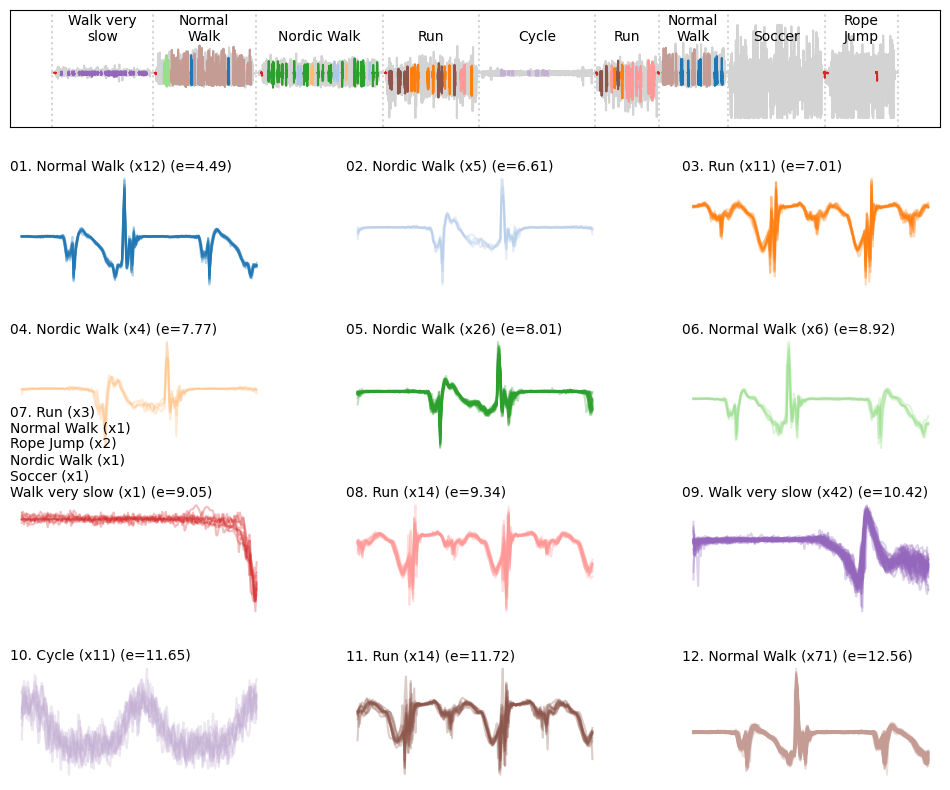

In [22]:
def plot_topn(topn: ScampiTopN, changepoints: np.array, annotations, fname=None):
    import matplotlib.gridspec as gridspec

    if topn.top_N <= 10:
        colors = sns.color_palette("tab10")
    else:
        colors = sns.color_palette("tab20")

    nrows = 1 + int(np.ceil(topn.top_N / 3))
    fig = plt.figure(figsize=(12, 2*nrows))

    # Create a GridSpec with 4 rows and 3 columns
    gs = gridspec.GridSpec(nrows, 3, figure=fig, hspace=0.4, wspace=0.3)

    # Top row: single plot spanning all 3 columns
    ax_top = fig.add_subplot(gs[0, :])
    # ax_top.set_title("Top Plot")
    ax_top.plot(topn.series, c="lightgray")
    for t in changepoints:
        ax_top.axvline(t, linestyle="dotted", c="lightgray")
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_ylim(-180, 200)
    for annotation, (b, e) in zip(annotations, 
                                  zip(changepoints[:-1], changepoints[1:])):
        x = (b + e) / 2
        ax_top.annotate(annotation, xy=(x, 100), fontsize=10, ha="center")

    # Bottom 3x3 grid occupying rows 1-3

    toplot = []
    for res in topn.found_motiflets:
        dists, motif_sets, elbow_points = res
        hsm = motif_sets[elbow_points[-1]][0][0]
        d = extent(topn.series, topn.window_size, hsm)
        toplot.append((d, hsm))
    toplot = sorted(toplot)

    axes = []
    # for i, res in enumerate(topn.found_motiflets):
    for i, (d, hsm) in enumerate(toplot):
        if i >= len(colors):
            break
        row = i // 3 + 1
        col = i % 3
        dists, motif_sets, elbow_points = res
        # hsm = motif_sets[elbow_points[-1]][0][0]
        # d = extent(topn.series, topn.window_size, hsm)
        ax = fig.add_subplot(gs[row, col])
        ax.axis("off")
        mlabels = dict()
        for j, t in enumerate(hsm):
            idx = np.arange(t, t+topn.window_size)
            subseq = topn.series[idx]
            ax.plot(znorm(subseq), c=colors[i], alpha=0.3)
            ax_top.plot(idx, subseq, c=colors[i])
            l = annotations[np.searchsorted(changepoints, t)-1]
            mlabels[l] = mlabels.get(l, 0) + 1
            # plt.plot(idx, subseq, c=colors[iteration])
        activity_label = "\n".join([
            "{} (x{})".format(k.replace("\n", " "), v)
            for k, v in mlabels.items()
        ])
        ax.set_title(f"{i+1:02d}. {activity_label} (e={d:.2f})",
                     fontsize=10, ha="left", loc="left", va="top")
        axes.append(ax)

    plt.tight_layout(pad=0)

    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches="tight")

    plt.show()

plot_topn(topn, changepoints, annotations) 

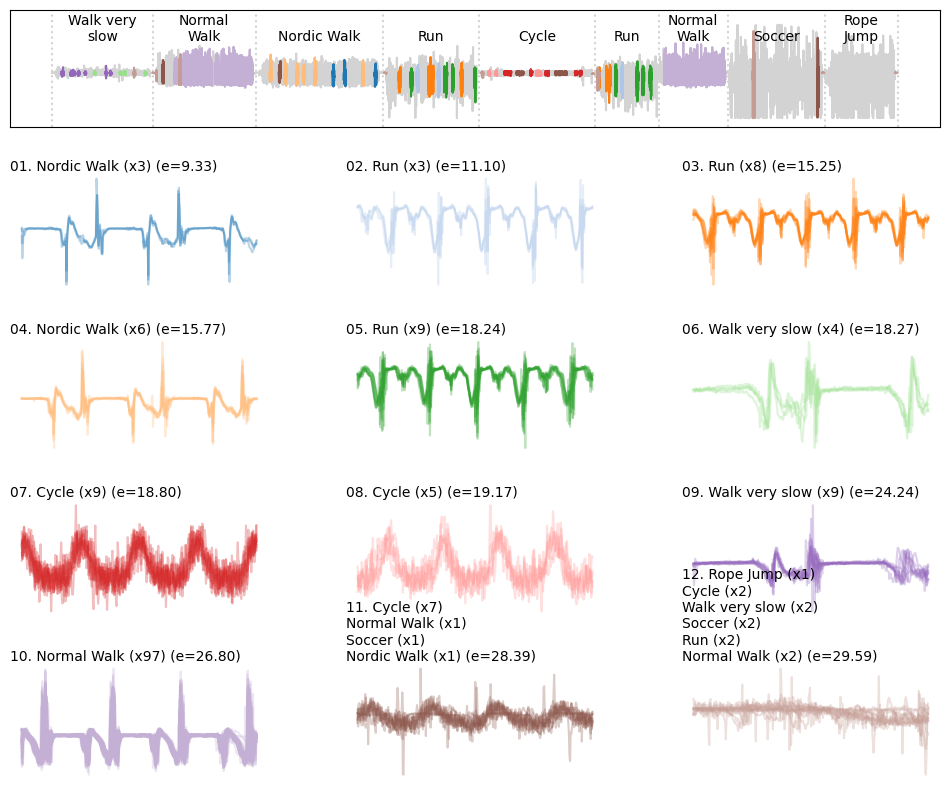

In [23]:
plot_topn(long_topn, changepoints, annotations, fname=f"human-activity-w{long_topn.window_size}.pdf") 

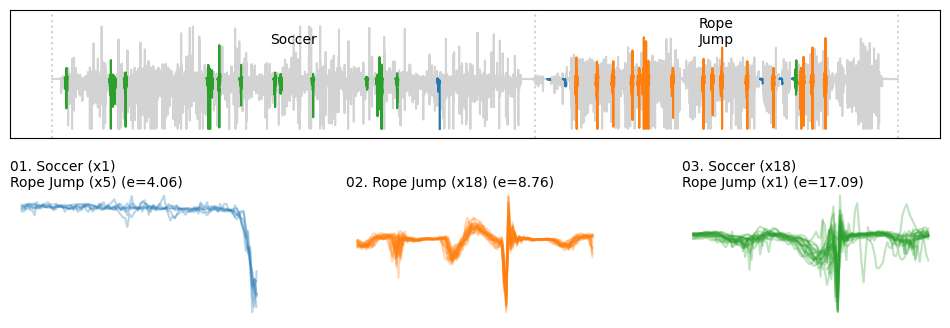

In [24]:
plot_topn(last_two_topn, changepoints=changepoints[-3:]-changepoints[-3], annotations=annotations[-2:], fname=f"human-activity-w{last_two_topn.window_size}-last-two.pdf")

In [25]:
def quantitative_evaluation(topn: ScampiTopN,
                            changepoints: np.array,
                            annotations):
    w = topn.window_size
    motiflets = []
    section_motiflets = dict()
    for res in topn.found_motiflets:
        dists, motif_sets, elbow_points = res
        hsm = motif_sets[elbow_points[-1]][0][0]   # highest support motiflet
        d = extent(topn.series, topn.window_size, hsm)
        mlabels = dict()
        for t in hsm:
            l = annotations[np.searchsorted(changepoints, t)-1]
            mlabels[l] = mlabels.get(l, 0) + 1
        best_count, best_label = max([(v, k) for k, v in mlabels.items()])
        section = section_motiflets.get(best_label, [])
        section.extend(hsm)
        section_motiflets[best_label] = section

    results = []
    for section, motiflets in section_motiflets.items():
        total = 0
        covered = 0
        flags = np.zeros_like(topn.series)
        for t in motiflets:
            flags[t:t+w] = 1
        for l, (b, e) in zip(annotations, zip(changepoints[:-1], changepoints[1:])):
            if l == section:
                covered += flags[b:e].sum()
                total += e - b
        results.append(dict(section=section, total=total, covered=covered))
    results = pd.DataFrame(results)
    results["fraction"] = results["covered"] / results["total"]
    return results

        # motiflets.append(dict(extent=d, motiflet=hsm, best_label=best_label))
    # motiflets = pd.DataFrame(motiflets).sort_values("extent")
    # return motiflets

In [26]:
quantitative_evaluation(topn, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,15233.0,0.431237
1,Nordic Walk,26234,6558.0,0.249981
2,Walk very\nslow,20657,8400.0,0.406642
3,Run,32797,8213.0,0.250419
4,Cycle,23864,2190.0,0.091770


In [27]:
quantitative_evaluation(long_topn, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,26835.0,0.759682
1,Run,32797,7684.0,0.234290
2,Cycle,23864,7940.0,0.332719
3,Nordic Walk,26234,3600.0,0.137226
4,Walk very\nslow,20657,5240.0,0.253667


In [28]:
quantitative_evaluation(last_two_topn, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,2368.0,0.067037
1,Walk very\nslow,20657,1795.0,0.086895


In [29]:
def find_dominant_window_sizes(X, offset=0.05):
    """Determine the Window-Size using dominant FFT-frequencies."""
    fourier = np.absolute(np.fft.fft(X))
    freqs = np.fft.fftfreq(X.shape[0], 1)
    print(freqs)
    print(fourier)
    plt.plot(fourier)
    # plt.semilogx()
    plt.show()

    coefs = []
    window_sizes = []

    for coef, freq in zip(fourier, freqs):
        if coef and freq > 0:
            coefs.append(coef)
            window_sizes.append(1 / freq)

    coefs = np.array(coefs)
    window_sizes = np.asarray(window_sizes, dtype=np.int64)

    idx = np.argsort(coefs)[::-1]
    return next(
        (
            int(window_size / 2)
            for window_size in window_sizes[idx]
            if window_size in range(20, int(X.shape[0] * offset))
        ),
        window_sizes[idx[0]],
    )

[ 0.00000000e+00  5.75125809e-06  1.15025162e-05 ... -1.72537743e-05
 -1.15025162e-05 -5.75125809e-06]
[1565629.13        151452.43104129  133217.73127537 ...  144470.14997634
  133217.73127537  151452.43104129]


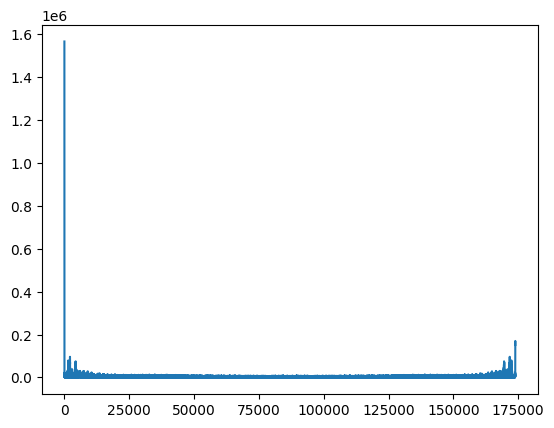

40

In [30]:
find_dominant_window_sizes(series)

dominant frequency 4.282979513700392 corresponding window 23.348232154769846


23

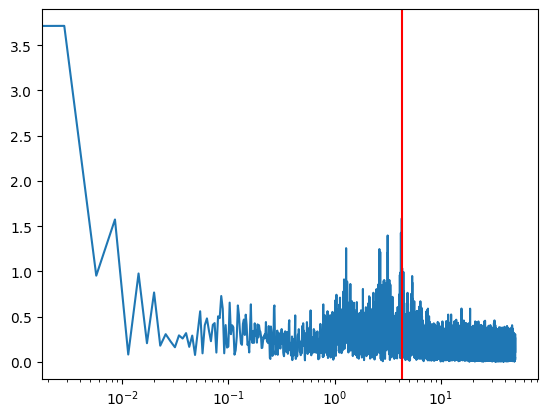

In [31]:
def find_dominant_window_sizes2(X, offset=0.05, fs=100, f_min=1e-2):
    """Determine the Window-Size using dominant FFT-frequencies."""
    X = X - X.mean()
    fourier = np.fft.rfft(X)
    freqs = np.fft.rfftfreq(X.shape[0], d=1/fs)

    fourier = np.abs(fourier) / X.shape[0]             # Normalize amplitude
    fourier[1:-1] *= 2                          # Double non-DC, non-Nyquist bins

    plt.plot(freqs,fourier)
    # plt.xlim(0, fs / 2)
    plt.semilogx()

    mask = freqs >= f_min
    dominant_freq = freqs[mask][np.argmax(fourier[mask])]
    print("dominant frequency", dominant_freq, "corresponding window", fs/dominant_freq)
    plt.axvline(dominant_freq, color="red")
    ws = int(round(fs / dominant_freq))
    return ws

    # coefs = []
    # window_sizes = []

    # for coef, freq in zip(fourier, freqs):
    #     if coef and freq > 0:
    #         coefs.append(coef)
    #         window_sizes.append(fs / freq)

    # coefs = np.array(coefs)
    # window_sizes = np.asarray(window_sizes, dtype=np.int64)

    # idx = np.argsort(coefs)[::-1]
    # print(window_sizes[idx])
    # ws = next(
    #     (
    #         int(window_size)
    #         for window_size in window_sizes[idx]
    #         if window_size in range(20, int(X.shape[0] * offset))
    #     ),
    #     window_sizes[idx[0]],
    # )
    # print(ws)

    # plt.axvline(fs/(ws), color="green", zorder=-1)

    # plt.show()
    # return ws

find_dominant_window_sizes2(series[changepoints[-3]:])

dominant frequency 1.2393961179007909 corresponding window 80.6844547563805


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 9.884715739
	Time for Test 5.082057045
masked timestamps: 14222.0
	Time for Build 9.557181088
	Time for Test 11.094479878
masked timestamps: 26696.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.646194681
	Time for Test 12.151531736
masked timestamps: 29758.0


...

	Time for Build 10.926313965
	Time for Test 11.745775882
masked timestamps: 87505.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 11.526055494
	Time for Test 11.768199512
masked timestamps: 97742.0


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 14.36901285
	Time for Test 13.256089188
masked timestamps: 103163.0
	Time for Build 11.632859675
	Time for Test 11.799383014
masked timestamps: 113822.0


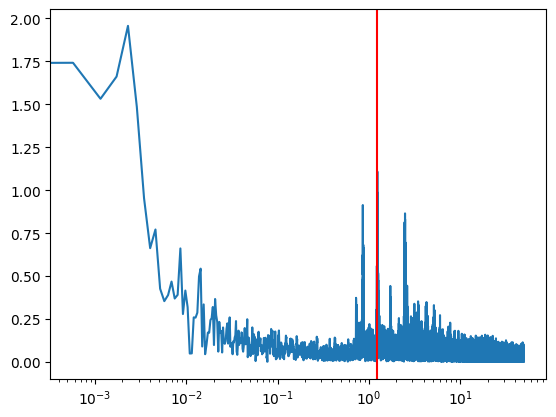

In [32]:
long_topn_alt = ScampiTopN(series, 100, 4*find_dominant_window_sizes2(series), 12)
while next(long_topn_alt) is not None:
    pass

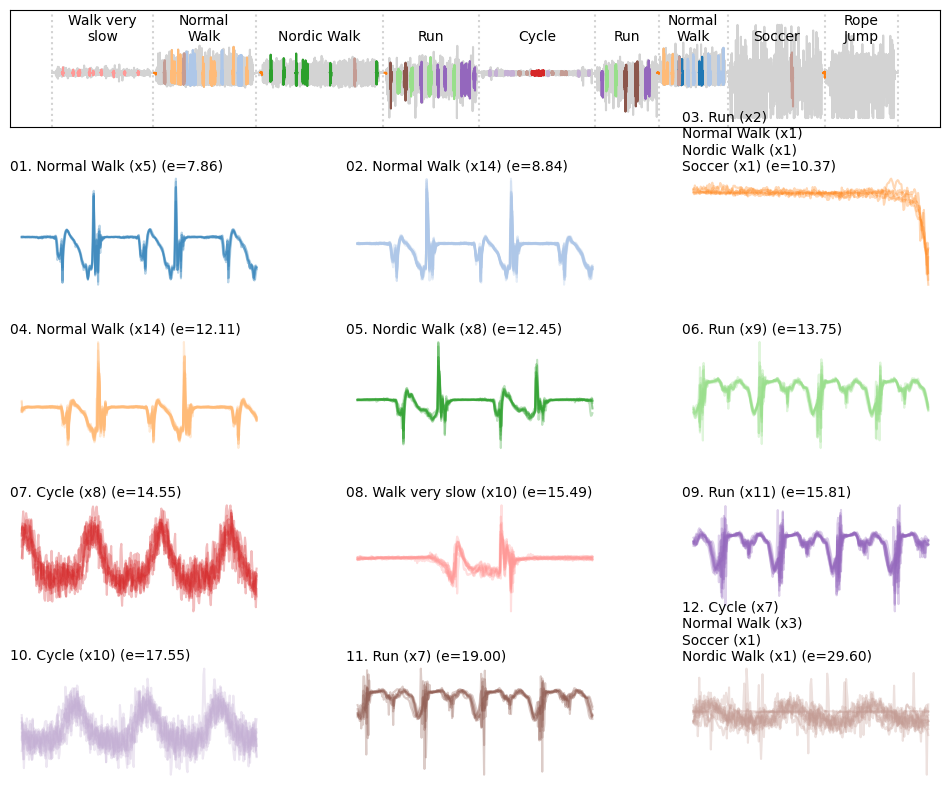

In [33]:
plot_topn(long_topn_alt, changepoints, annotations, fname=f"human-activity-w{long_topn_alt.window_size}.pdf") 

dominant frequency 4.282979513700392 corresponding window 23.348232154769846


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.882230055
	Time for Test 1.029844205
masked timestamps: 1035.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.660793837
	Time for Test 0.73754844
masked timestamps: 17544.0


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.593635419
	Time for Test 0.460778661
masked timestamps: 24825.0


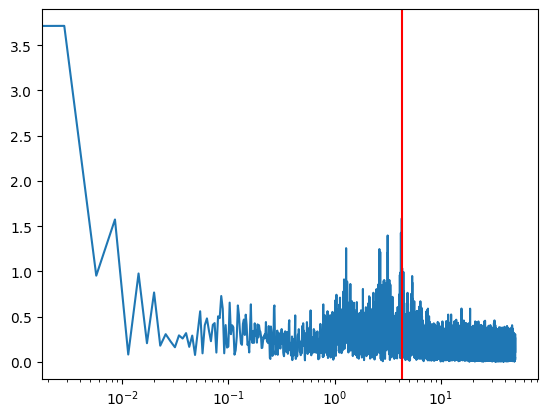

In [34]:
# last_two_alt = series[changepoints[-3]:]
last_two_alt_topn = ScampiTopN(
    last_two, 
    k_max=100, 
    window_size=3*find_dominant_window_sizes2(last_two), 
    top_N=3
)
while next(last_two_alt_topn) is not None:
    pass

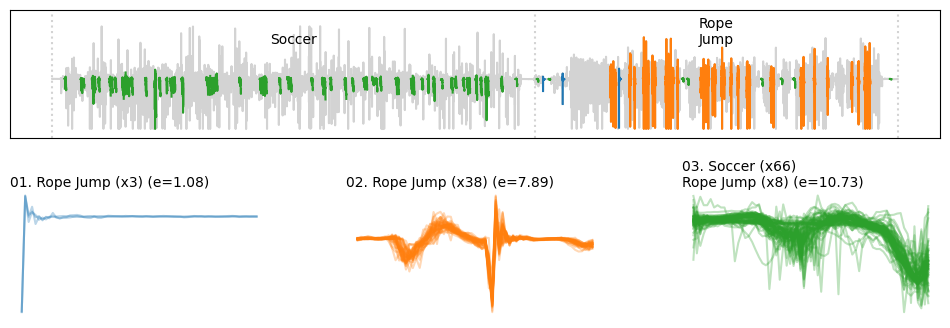

In [35]:
plot_topn(last_two_alt_topn, changepoints=changepoints[-3:]-changepoints[-3], annotations=annotations[-2:], fname=f"human-activity-w{last_two_alt_topn.window_size}-last-two.pdf")

dominant frequency 1.2393961179007909 corresponding window 80.6844547563805


405

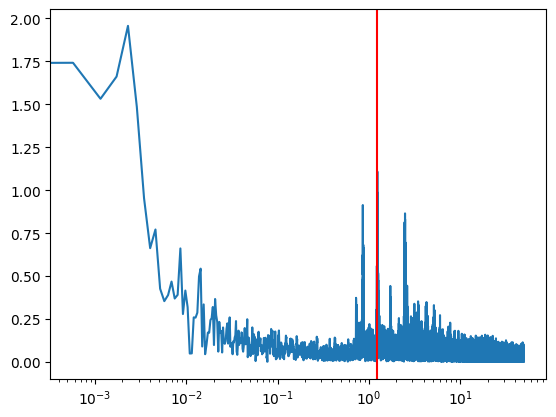

In [36]:
5*find_dominant_window_sizes2(series)

dominant frequency 4.282979513700392 corresponding window 23.348232154769846


115

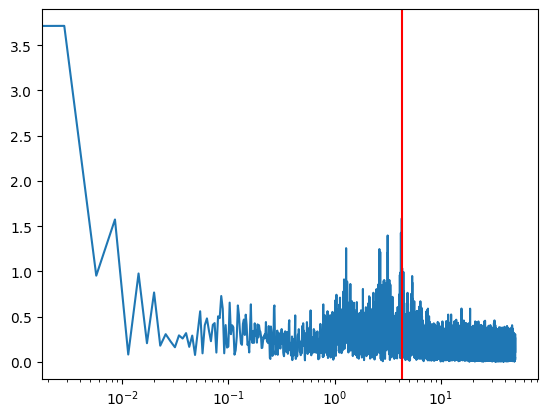

In [37]:
5*find_dominant_window_sizes2(series[changepoints[-3]:])